# Comparison plots from pooled_path_comparison.csv

Reads the comparison table. Does not retrain.

The main plots are pooled-path scores at **7 / 14 / 30** days (the whole 1...H forecast, not day H alone). Persistence is the naive floor on the tree origin set: PM₂.₅ at origin *t* held flat. Climatology is the training mean PM₂.₅ for that day of year only (`climatology_baseline.ipynb`). Lower is better for MAE, RMSE, MSE, MAPE. Higher is better for R². MBE is signed bias. 0 means unbiased. Positive means the model runs high.

**1-day** is a different job (`lead_1`). It sits in a short side note at the bottom, with its own table and one combined plot. LSTM and GRU have no 1-day row.

Feature ranks come from `pooled_path_feature_importance_ranks.csv` (built in `pooled_path_comparison.ipynb`).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path(".")
df = pd.read_csv(HERE / "pooled_path_comparison.csv")

PREFERRED = [
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU",
    "CNN-LSTM",
    "Transformer",
    "Persistence",
    "Climatology",
]
COLORS = {
    "Random Forest": "#0072B2",
    "XGBoost": "#E69F00",
    "LSTM": "#56B4E9",
    "GRU": "#CC79A7",
    "CNN-LSTM": "#009E73",
    "Transformer": "#D55E00",
    "Persistence": "#4D4D4D",
    "Climatology": "#8172B3",
}
HORIZONS = [7, 14, 30]
MARKERS = {7: "s", 14: "D", 30: "^"}

path = df[df["Horizon_Days"].isin(HORIZONS)].copy()
one_day = df[df["Horizon_Days"] == 1].copy()

MODELS = [m for m in PREFERRED if m in set(path["Model"])]
MODELS_1D = [m for m in PREFERRED if m in set(one_day["Model"])]

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

print("Pooled path")
display(path[["Model", "Horizon_Days", "Evaluation", "MAE", "RMSE", "MSE", "R2", "MAPE", "MBE"]].round(3))


Pooled path


,Model,Horizon_Days,Evaluation,MAE,RMSE,MSE,R2,MAPE,MBE
5,CNN-LSTM,7,pooled_path,3.827,6.393,40.866,0.106,45.023,-1.063
6,XGBoost,7,pooled_path,4.030,6.347,40.281,0.224,49.835,-0.419
7,Random Forest,7,pooled_path,4.062,6.270,39.315,0.243,51.357,-0.238
8,GRU,7,pooled_path,4.136,6.521,42.523,0.180,48.066,-0.969
9,LSTM,7,pooled_path,4.321,7.085,50.193,0.032,47.443,-1.391
10,Transformer,7,pooled_path,4.563,6.485,42.057,0.080,64.775,0.684
11,Persistence,7,pooled_path,4.884,8.002,64.039,-0.233,60.239,0.030
12,CNN-LSTM,14,pooled_path,3.912,6.648,44.198,0.028,45.759,-1.068
13,GRU,14,pooled_path,4.049,6.820,46.508,0.100,42.159,-1.746
14,XGBoost,14,pooled_path,4.192,6.617,43.779,0.149,50.923,-0.586


In [2]:
def values(model, col):
    out = []
    for h in HORIZONS:
        sub = path.loc[(path["Model"] == model) & (path["Horizon_Days"] == h), col]
        out.append(float(sub.iloc[0]) if len(sub) else np.nan)
    return out


def line_metric(col, ylabel, better, zero_line=False):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for model in MODELS:
        y = np.asarray(values(model, col), dtype=float)
        ax.plot(
            HORIZONS,
            y,
            marker="x" if model in ("Persistence", "Climatology") else "o",
            linestyle=":" if model == "Climatology" else ("--" if model == "Persistence" else "-"),
            color=COLORS[model],
            label=model,
        )
    if zero_line:
        ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(HORIZONS)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{col}  ({better})")
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    plt.show()


def grouped_bars(col, ylabel, better, zero_line=False):
    fig, ax = plt.subplots(figsize=(9, 4.4))
    x = np.arange(len(HORIZONS))
    n = len(MODELS)
    width = 0.8 / n
    for i, model in enumerate(MODELS):
        ax.bar(
            x + (i - (n - 1) / 2) * width,
            values(model, col),
            width,
            color=COLORS[model],
            label=model,
            hatch=".." if model == "Climatology" else ("//" if model == "Persistence" else None),
        )
    if zero_line:
        ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(HORIZONS)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{col}  ({better})")
    ax.legend(frameon=False, ncol=4)
    fig.tight_layout()
    plt.show()


## Each metric vs horizon

Pooled path only. Lines for MAE, RMSE, MSE, MAPE, and R². Grouped bars for MBE because the sign (over vs under) is the point.


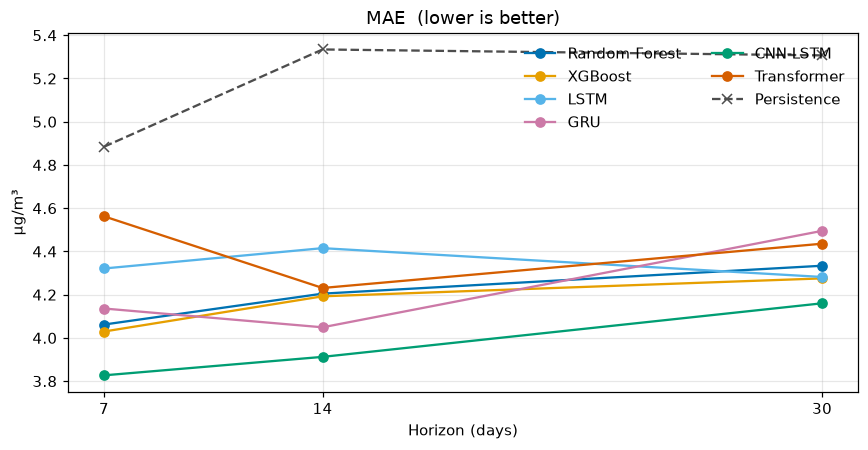

In [3]:
line_metric("MAE", "µg/m³", "lower is better")


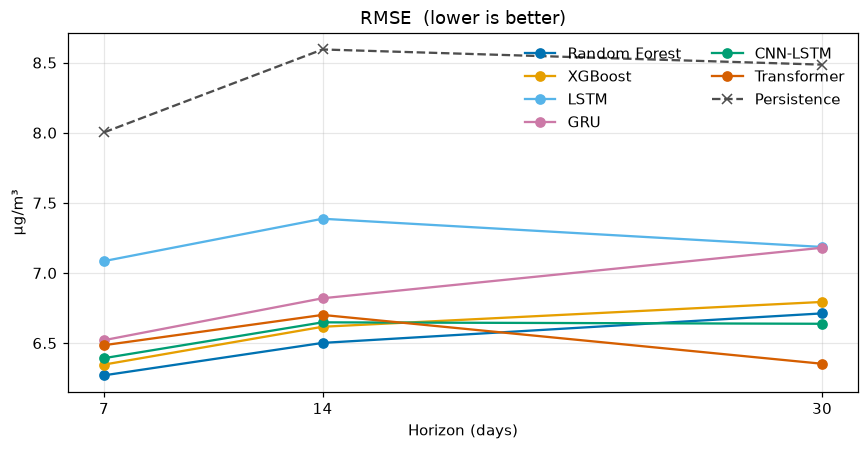

In [4]:
line_metric("RMSE", "µg/m³", "lower is better")


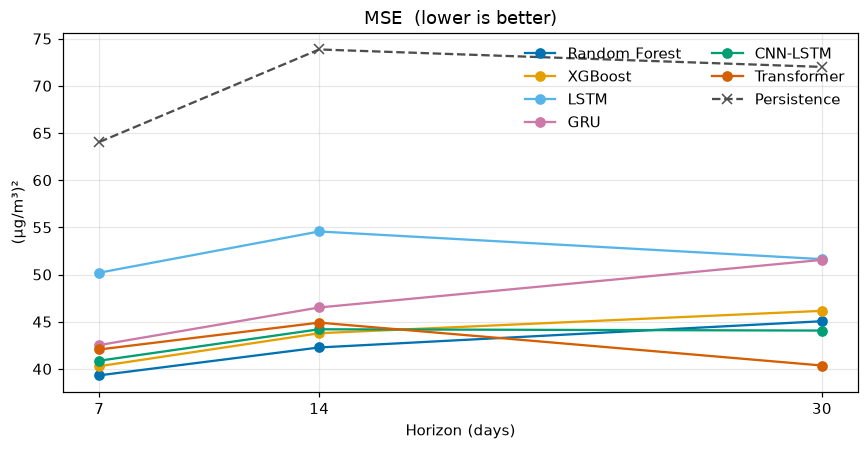

In [5]:
line_metric("MSE", "(µg/m³)²", "lower is better")


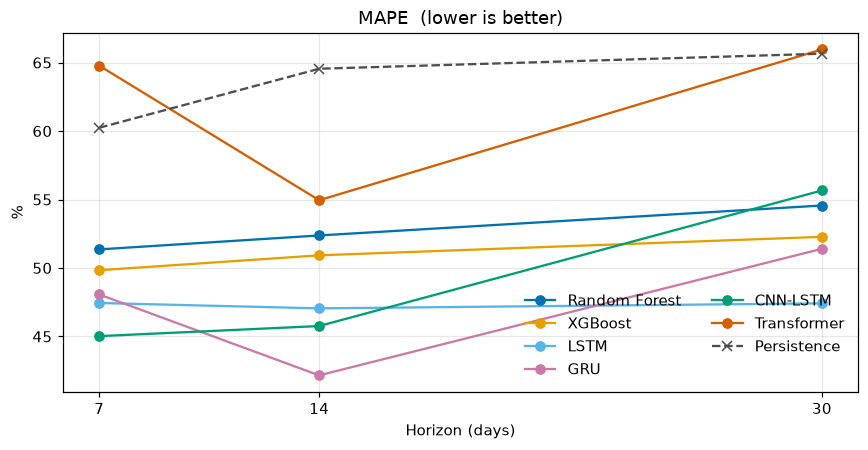

In [6]:
line_metric("MAPE", "%", "lower is better")


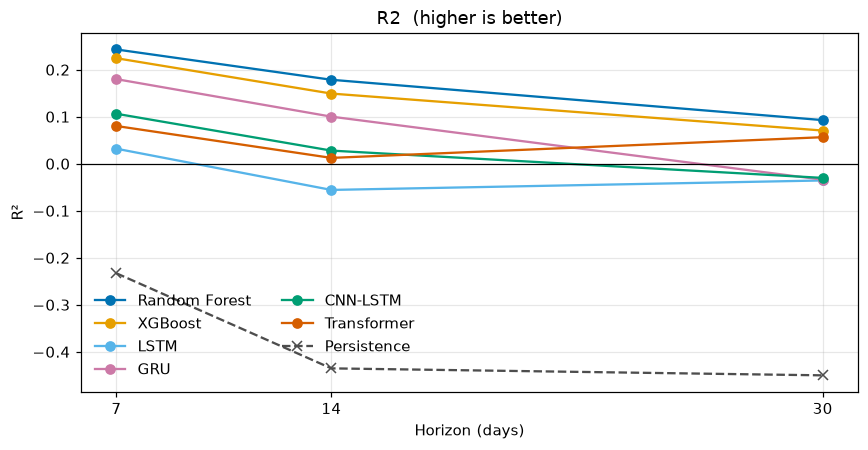

In [7]:
line_metric("R2", "R²", "higher is better", zero_line=True)


In [8]:
#print random forest R² values for different horizons
import pandas as pd
df = pd.read_csv(HERE / "pooled_path_comparison_presentable.csv")
print(df[(df["Model"] == "Random Forest")][["Horizon (days)", "R2"]])

FileNotFoundError: [Errno 2] No such file or directory: 'model_training/pooled_path_comparison_presentable.csv'

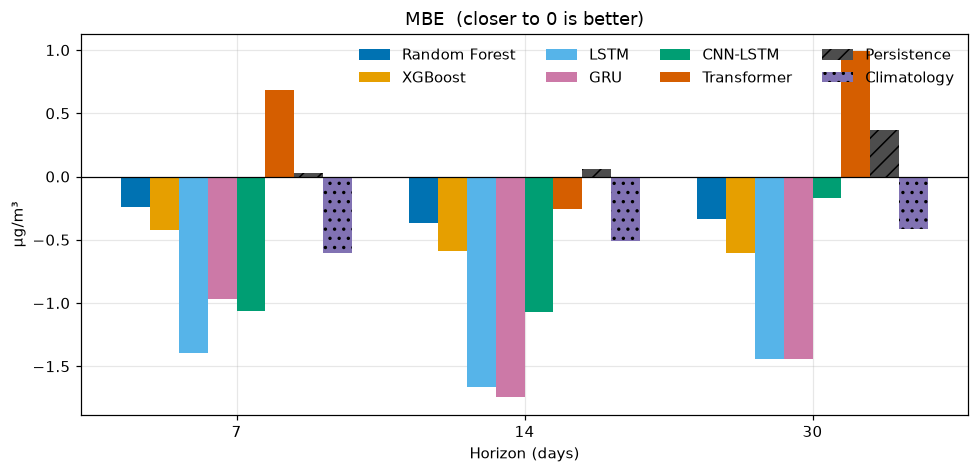

In [ ]:
grouped_bars("MBE", "µg/m³", "closer to 0 is better", zero_line=True)


## Combinations

MAE grouped by horizon is the ranking chart. MAPE grouped the same way, because percent error can reorder the models. MAE vs RMSE shows when those two disagree, large misses versus many moderate errors. RMSE/MAE is a tail index. Gaussian noise sits near 1.25. Higher means a heavier tail. MAE vs R² pairs typical error with explained variance.


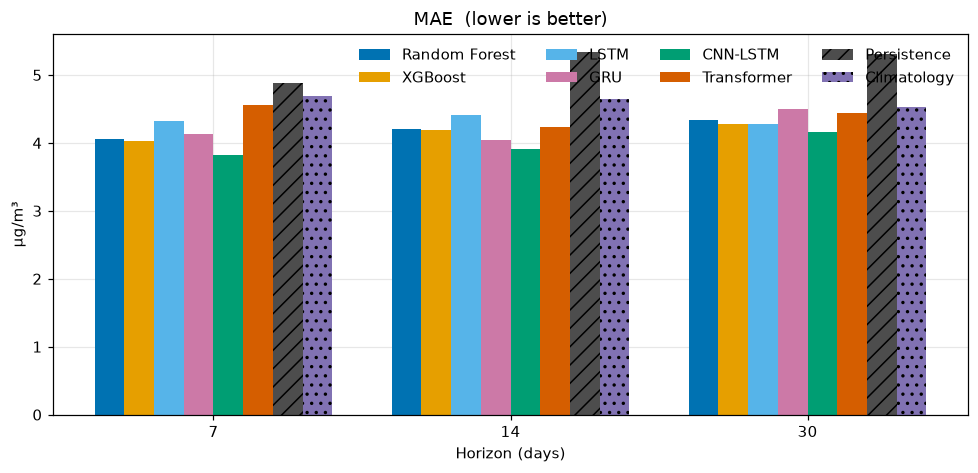

In [ ]:
grouped_bars("MAE", "µg/m³", "lower is better")


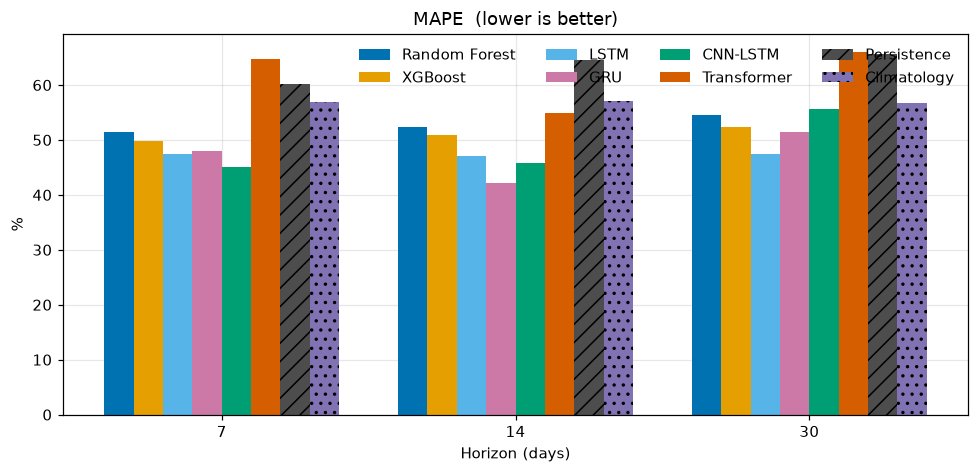

In [ ]:
grouped_bars("MAPE", "%", "lower is better")


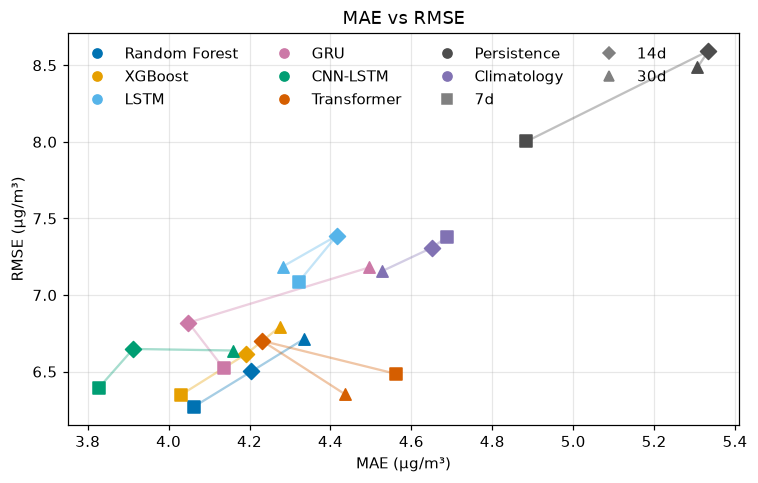

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for model in MODELS:
    sub = path[path["Model"] == model]
    ax.plot(sub["MAE"], sub["RMSE"], color=COLORS[model], alpha=0.35)
    for _, row in sub.iterrows():
        ax.scatter(
            row["MAE"],
            row["RMSE"],
            color=COLORS[model],
            marker=MARKERS[int(row["Horizon_Days"])],
            s=55,
            zorder=3,
        )
handles = [
    plt.Line2D([0], [0], color=COLORS[m], marker="o", linestyle="", label=m)
    for m in MODELS
] + [
    plt.Line2D([0], [0], color="grey", marker=mk, linestyle="", label=f"{h}d")
    for h, mk in MARKERS.items()
]
ax.set_xlabel("MAE (µg/m³)")
ax.set_ylabel("RMSE (µg/m³)")
ax.set_title("MAE vs RMSE")
ax.legend(handles=handles, frameon=False, ncol=4)
fig.tight_layout()
plt.show()


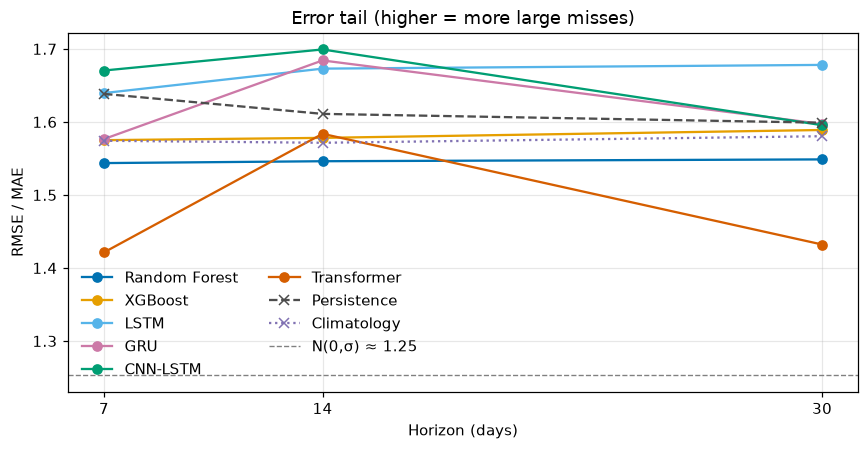

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for model in MODELS:
    mae = np.asarray(values(model, "MAE"), dtype=float)
    rmse = np.asarray(values(model, "RMSE"), dtype=float)
    ax.plot(
        HORIZONS,
        rmse / mae,
            marker="x" if model in ("Persistence", "Climatology") else "o",
            linestyle=":" if model == "Climatology" else ("--" if model == "Persistence" else "-"),
        color=COLORS[model],
        label=model,
    )
ax.axhline(1.253, color="grey", linestyle="--", linewidth=0.9, label="N(0,σ) ≈ 1.25")
ax.set_xticks(HORIZONS)
ax.set_xlabel("Horizon (days)")
ax.set_ylabel("RMSE / MAE")
ax.set_title("Error tail (higher = more large misses)")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


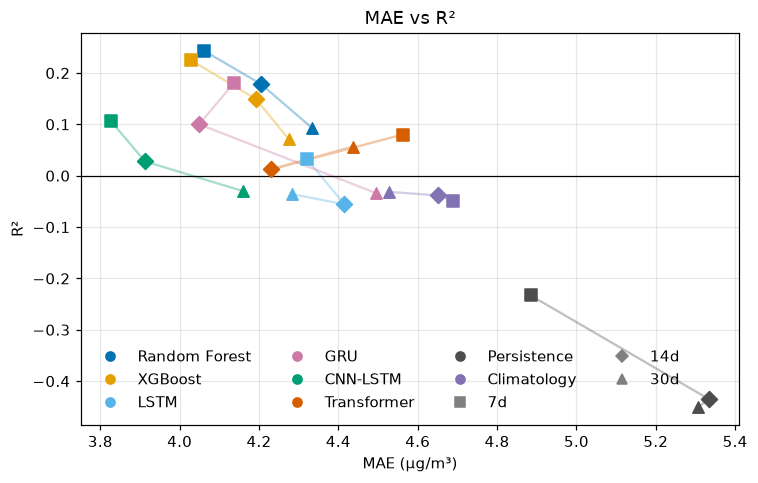

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for model in MODELS:
    sub = path[path["Model"] == model]
    ax.plot(sub["MAE"], sub["R2"], color=COLORS[model], alpha=0.35)
    for _, row in sub.iterrows():
        ax.scatter(
            row["MAE"],
            row["R2"],
            color=COLORS[model],
            marker=MARKERS[int(row["Horizon_Days"])],
            s=55,
            zorder=3,
        )
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("MAE (µg/m³)")
ax.set_ylabel("R²")
ax.set_title("MAE vs R²")
handles = [
    plt.Line2D([0], [0], color=COLORS[m], marker="o", linestyle="", label=m)
    for m in MODELS
] + [
    plt.Line2D([0], [0], color="grey", marker=mk, linestyle="", label=f"{h}d")
    for h, mk in MARKERS.items()
]
ax.legend(handles=handles, frameon=False, ncol=4)
fig.tight_layout()
plt.show()


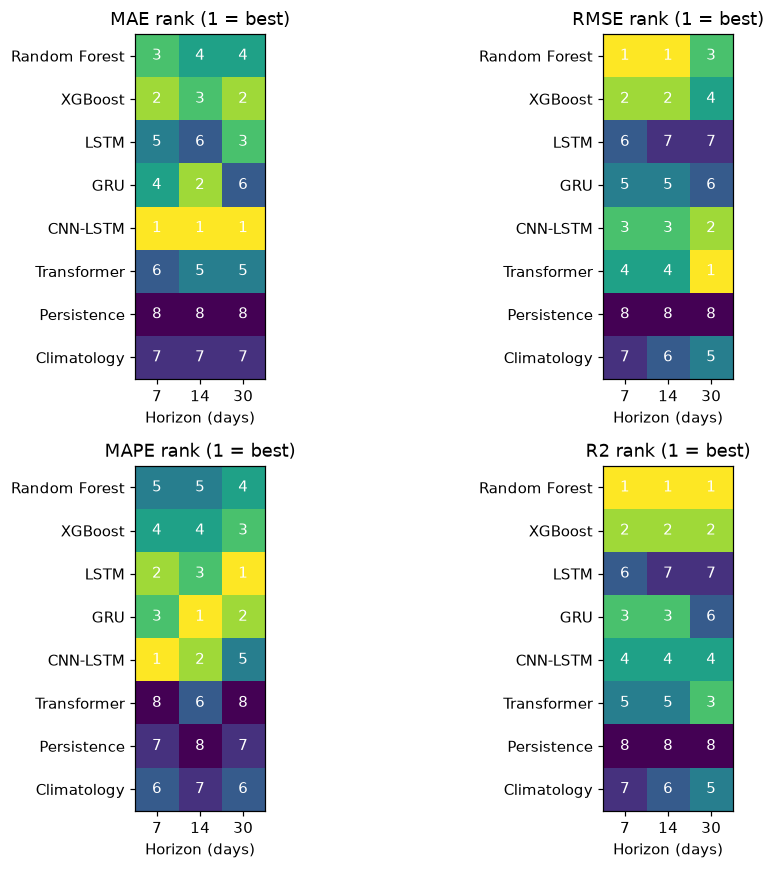

In [ ]:
rank_metrics = {"MAE": True, "RMSE": True, "MAPE": True, "R2": False}
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (col, low_is_best) in zip(axes.ravel(), rank_metrics.items()):
    table = path.pivot(index="Model", columns="Horizon_Days", values=col).reindex(
        index=MODELS, columns=HORIZONS
    )
    ranks = table.rank(axis=0, ascending=low_is_best, method="min")
    ax.imshow(
        np.ma.masked_invalid(ranks.to_numpy()),
        cmap="viridis_r",
        vmin=1,
        vmax=len(MODELS),
    )
    ax.set_xticks(range(len(HORIZONS)))
    ax.set_xticklabels(HORIZONS)
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels(MODELS)
    ax.set_xlabel("Horizon (days)")
    ax.set_title(f"{col} rank (1 = best)")
    ax.grid(False)
    for i in range(len(MODELS)):
        for j in range(len(HORIZONS)):
            val = ranks.iloc[i, j]
            if pd.isna(val):
                continue
            ax.text(j, i, int(val), ha="center", va="center", color="white")
fig.tight_layout()
plt.show()


## Feature importance: mean rank, top 5

From `pooled_path_feature_importance_ranks.csv`. Rank 1 is the feature with the largest permutation MAE increase **within that model**. The bar is that rank. The black tick is the mean across models that have a file. LSTM and GRU are not in the file.


In [ ]:
imp_ranks = pd.read_csv(HERE / "pooled_path_feature_importance_ranks.csv", comment="#")
IMP_HORIZONS = [1, 7, 14, 30]
IMP_MODELS = ["Random Forest", "XGBoost", "CNN-LSTM", "Transformer"]
RANK_COL = {
    "Random Forest": "rf_rank",
    "XGBoost": "xgb_rank",
    "CNN-LSTM": "cnn_lstm_rank",
    "Transformer": "transformer_rank",
}

for h in IMP_HORIZONS:
    top = imp_ranks.loc[imp_ranks["horizon_days"] == h].nsmallest(5, "mean_rank")
    if top.empty:
        continue
    print(f"{h}-day top 5 (mean rank)")
    show = ["feature", "mean_rank", "n_models", *RANK_COL.values()]
    display(top[show].round(2))


1-day top 5 (mean rank)


,feature,mean_rank,n_models,rf_rank,xgb_rank,cnn_lstm_rank,transformer_rank
0,pm25_rollmean3,1.0,2,1.0,1.0,NaN,NaN
1,mean_wind_speed_knots,2.0,2,2.0,2.0,NaN,NaN
2,wind_speed_max_knots,3.0,2,3.0,3.0,NaN,NaN
3,temperature_max_c,4.0,2,4.0,4.0,NaN,NaN
4,temperature_avg_c,6.0,2,6.0,6.0,NaN,NaN


7-day top 5 (mean rank)


,feature,mean_rank,n_models,rf_rank,xgb_rank,cnn_lstm_rank,transformer_rank
40,day_of_year,3.00,4,3.0,7.0,1.0,1.0
41,temperature_avg_c,3.25,4,1.0,1.0,4.0,7.0
42,temperature_min_c,4.00,4,2.0,3.0,5.0,6.0
43,week_of_year,5.00,4,8.0,8.0,2.0,2.0
44,day_of_month,7.00,4,6.0,2.0,7.0,13.0


14-day top 5 (mean rank)


,feature,mean_rank,n_models,rf_rank,xgb_rank,cnn_lstm_rank,transformer_rank
80,doy_cos,5.50,4,2.0,5.0,7.0,8.0
81,mean_relative_humidity_pct,10.75,4,8.0,3.0,21.0,11.0
82,month,11.75,4,7.0,6.0,1.0,33.0
83,week_of_year,11.75,4,3.0,4.0,5.0,35.0
84,day_of_month,12.00,4,12.0,8.0,3.0,25.0


30-day top 5 (mean rank)


,feature,mean_rank,n_models,rf_rank,xgb_rank,cnn_lstm_rank,transformer_rank
120,doy_cos,3.50,4,1.0,1.0,7.0,5.0
121,day_of_month,9.25,4,5.0,2.0,9.0,21.0
122,mean_relative_humidity_pct,9.50,4,6.0,7.0,14.0,11.0
123,day_of_year,10.00,4,2.0,24.0,1.0,13.0
124,week_of_year,10.50,4,20.0,8.0,5.0,9.0


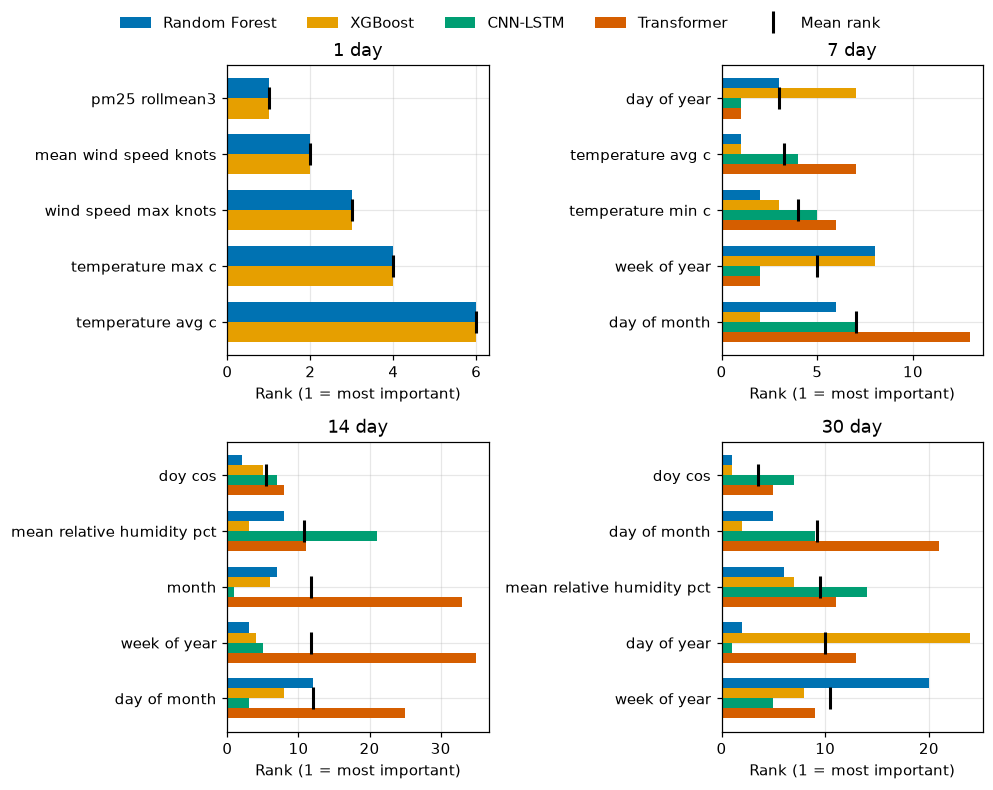

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.0), sharex=False)
for ax, h in zip(axes.ravel(), IMP_HORIZONS):
    sub = imp_ranks.loc[imp_ranks["horizon_days"] == h]
    top = sub.nsmallest(5, "mean_rank")
    models_here = [
        m for m in IMP_MODELS
        if RANK_COL[m] in top.columns and top[RANK_COL[m]].notna().any()
    ]
    if top.empty or not models_here:
        ax.set_axis_off()
        ax.set_title(f"{h} day (no ranks)")
        continue
    y = np.arange(len(top))
    n = len(models_here)
    height = 0.72 / n
    for i, model in enumerate(models_here):
        ax.barh(
            y + (i - (n - 1) / 2) * height,
            top[RANK_COL[model]].to_numpy(dtype=float),
            height,
            color=COLORS[model],
            label=model,
        )
    ax.plot(
        top["mean_rank"].to_numpy(dtype=float),
        y,
        linestyle="none",
        marker="|",
        markersize=14,
        markeredgewidth=2,
        color="black",
        label="Mean rank",
        zorder=3,
    )
    ax.set_yticks(y)
    ax.set_yticklabels([name.replace("_", " ") for name in top["feature"]])
    ax.invert_yaxis()
    ax.set_title(f"{h} day")
    ax.set_xlabel("Rank (1 = most important)")

handles, labels = [], []
seen = set()
for ax in axes.ravel():
    h, lab = ax.get_legend_handles_labels()
    for hi, li in zip(h, lab):
        if li not in seen:
            seen.add(li)
            handles.append(hi)
            labels.append(li)
order = [*IMP_MODELS, "Mean rank"]
by_label = dict(zip(labels, handles))
labels = [lab for lab in order if lab in by_label]
handles = [by_label[lab] for lab in labels]
fig.legend(handles, labels, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.tight_layout()
plt.show()


## Side note: 1-day

Next-day error only. Not a pooled path. LSTM and GRU are omitted. Persistence is yesterday's PM₂.₅. Climatology is the training mean for that day of year. RF, XGBoost, and CNN-LSTM sit on top of each other. The transformer does not.


,MAE,RMSE,MSE,R2,MAPE,MBE
Model,,,,,,
Random Forest,3.154,5.102,26.030,0.494,41.353,0.064
XGBoost,3.155,5.173,26.762,0.480,40.898,-0.022
CNN-LSTM,3.166,4.880,23.813,0.475,42.109,0.124
Transformer,4.364,6.773,45.875,-0.011,56.937,-0.178
Persistence,3.124,5.674,32.191,0.374,37.635,0.000
Climatology,4.675,7.344,53.938,-0.049,56.929,-0.613


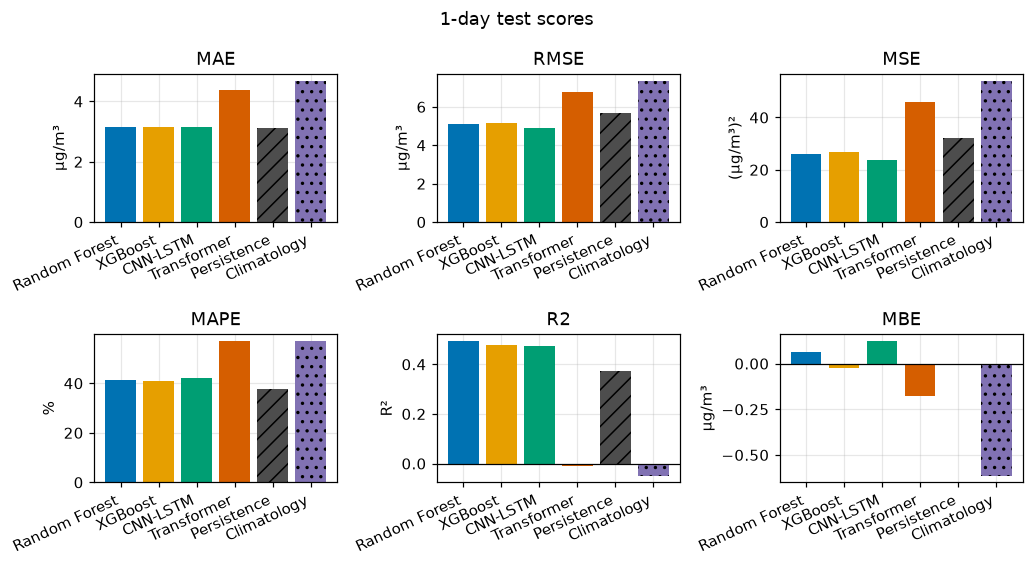

In [ ]:
one_day_tbl = (
    one_day.set_index("Model")
    .reindex(MODELS_1D)[["MAE", "RMSE", "MSE", "R2", "MAPE", "MBE"]]
    .round(3)
)
display(one_day_tbl)

panels = [
    ("MAE", "µg/m³", False),
    ("RMSE", "µg/m³", False),
    ("MSE", "(µg/m³)²", False),
    ("MAPE", "%", False),
    ("R2", "R²", True),
    ("MBE", "µg/m³", True),
]
fig, axes = plt.subplots(2, 3, figsize=(9.5, 5.2))
x = np.arange(len(MODELS_1D))
for ax, (col, ylab, zero_line) in zip(axes.ravel(), panels):
    vals = [float(one_day.loc[one_day["Model"] == m, col].iloc[0]) for m in MODELS_1D]
    ax.bar(
        x,
        vals,
        color=[COLORS[m] for m in MODELS_1D],
        hatch=[".." if m == "Climatology" else ("//" if m == "Persistence" else None) for m in MODELS_1D],
    )
    if zero_line:
        ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS_1D, rotation=25, ha="right")
    ax.set_ylabel(ylab)
    ax.set_title(col)
fig.suptitle("1-day test scores")
fig.tight_layout()
plt.show()
